In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# use higher resolution images in notebooks
import maze_helper as mh




L_maze.txt


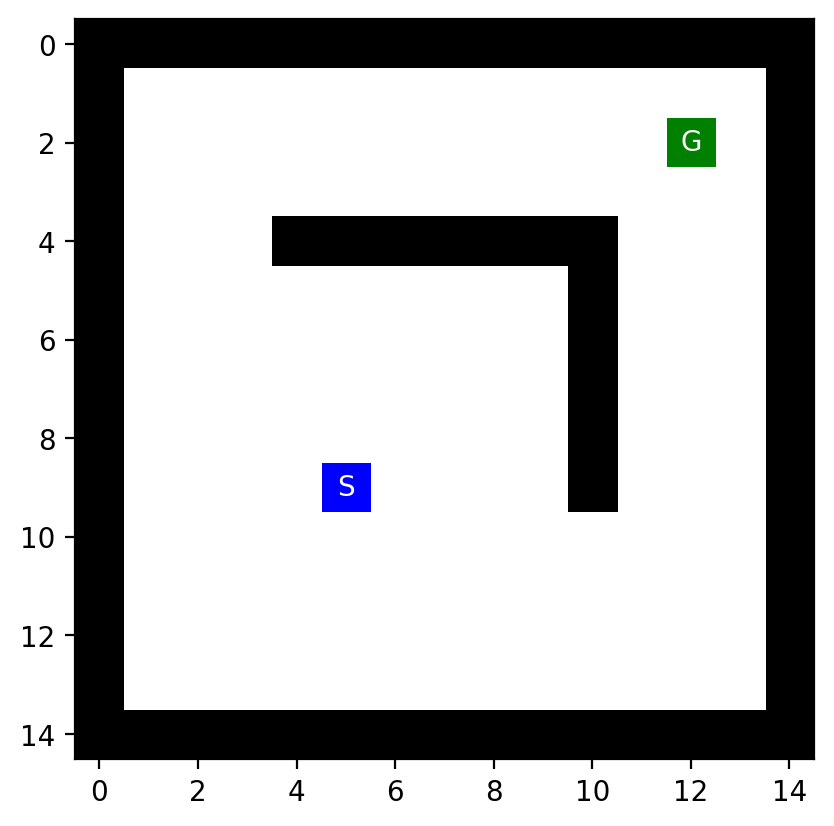

empty_maze.txt


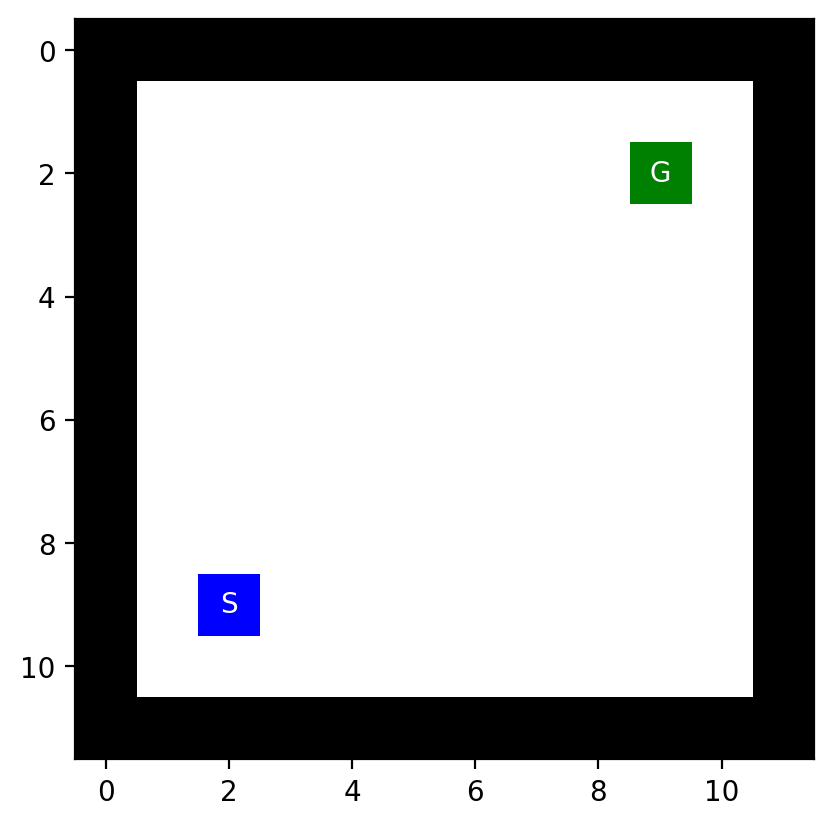

empty_maze_2.txt


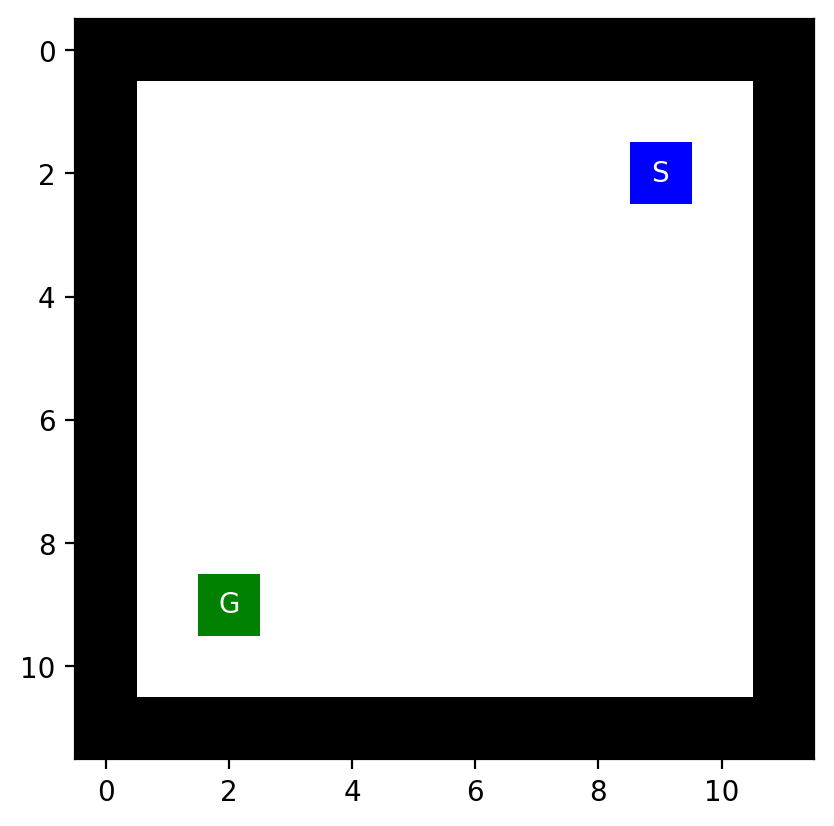

large_maze.txt


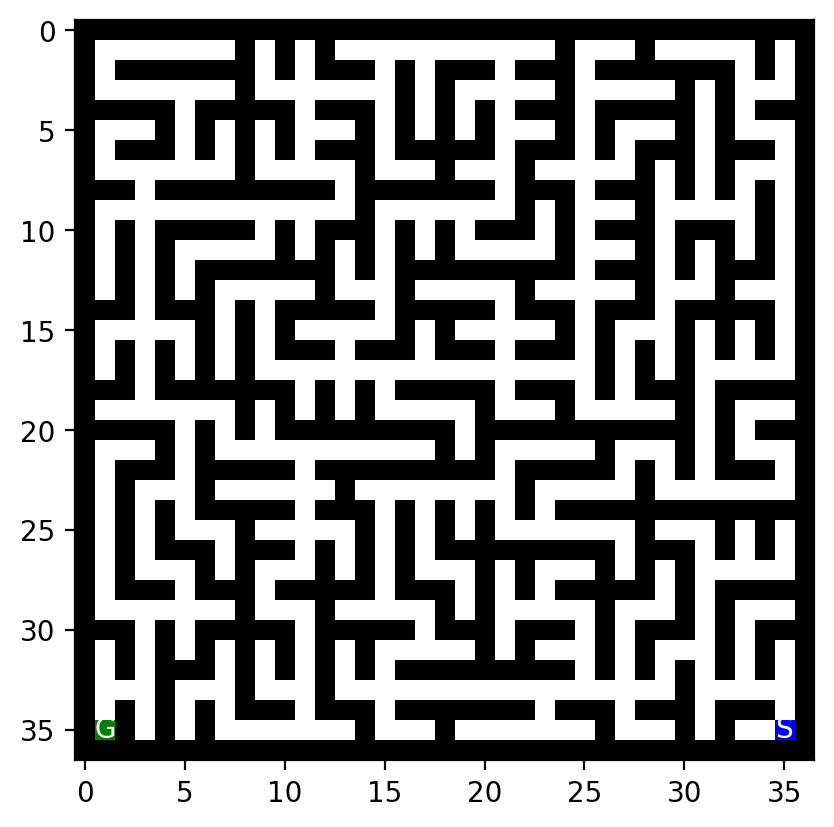

loops_maze.txt


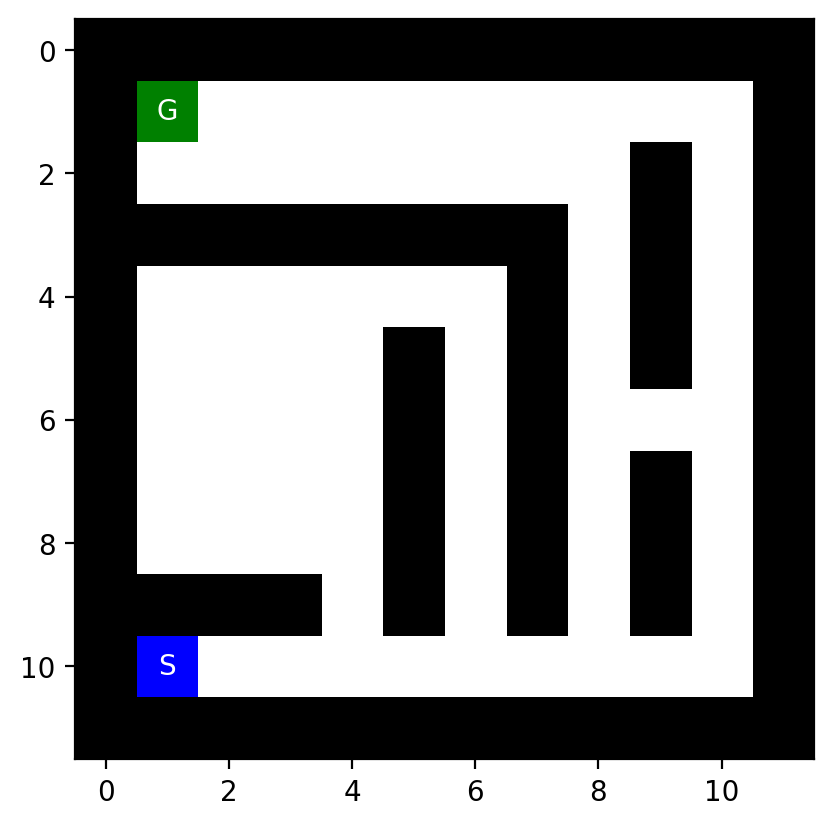

medium_maze.txt


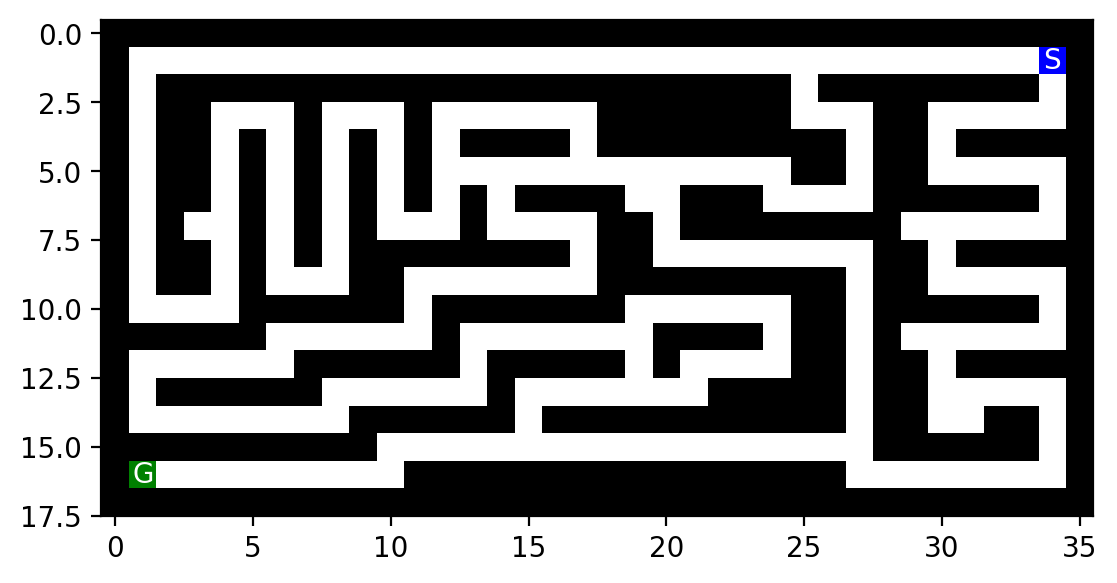

open_maze.txt


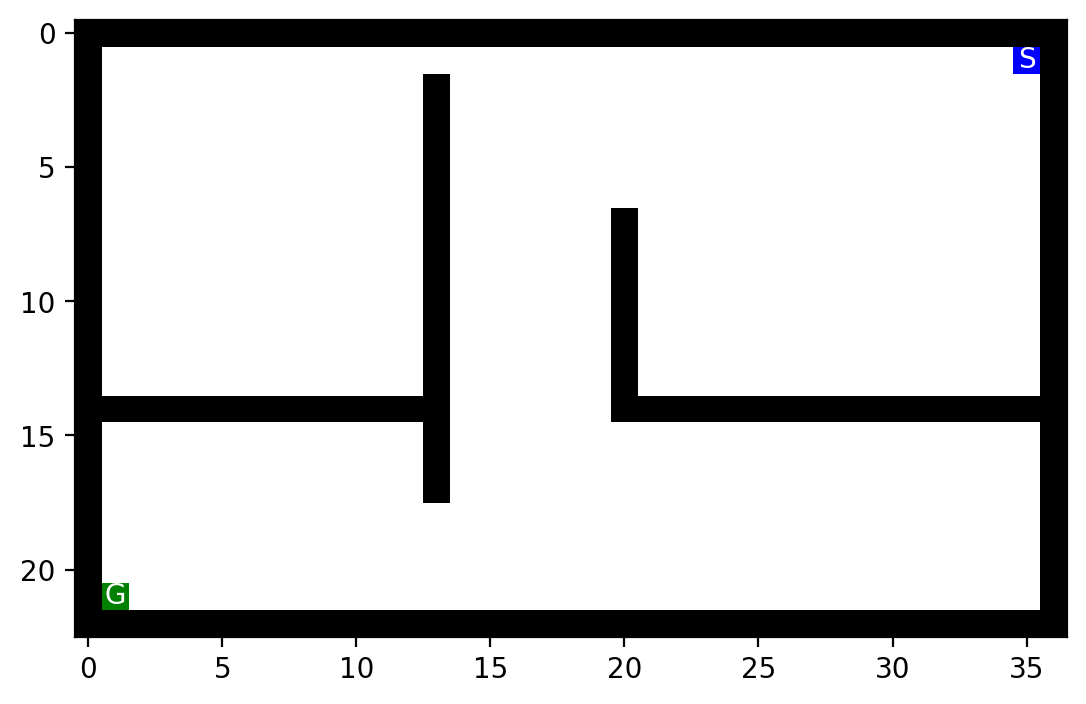

small_maze.txt


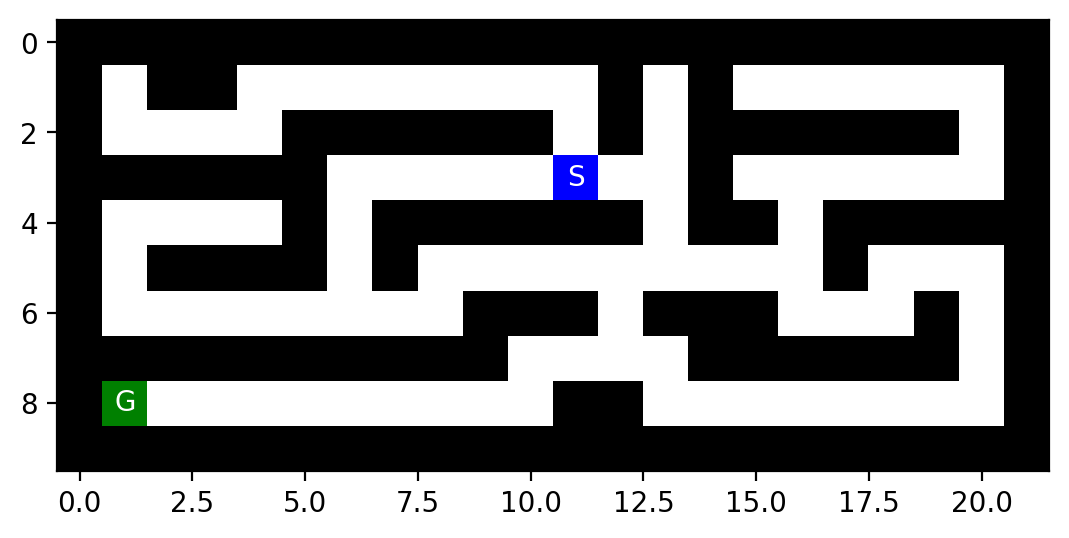

In [3]:
import os

def list_mazes(directory):
    txt_files = []
    for filename in os.listdir(directory):
        if filename.endswith(".txt"):
            txt_files.append(filename)
    txt_files.sort()
    return txt_files

mazes = list_mazes(".") #lấy tất cả file mê cung hiện tại chứa thư mục notebook

for maze_file in mazes:
    with open(maze_file, "r") as f:
        maze_str = f.read() #dùng dòng for đọc toàn bộ nội dung file thành một chuỗi 
    maze = mh.parse_maze(maze_str) # chuyển chuỗi thành ma trận 2 chiều. Mỗi phần tử là 1 kí tự X, S, G
    
    print(maze_file)
    
    mh.show_maze(maze) #vẽ mê cung

#### Xác định 5 thành phần của bài toán tìm kiếm

- Có 8 mê cung được hiển thị:
`small`, `medium`, `large`, `open`, `L`, `loops`, `empty`, `empty_2`.

- Trong đó, file `*.txt`: 
`X` là tường, 
`S` là điểm bắt đầu, 
`G` là đích, 
khoảng trắng là ô có thể di chuyển.

| Thành phần | Trong bài toán mê cung |
|---|---|
| **Trạng thái đầu** | Vị trí ô `S`, biểu diễn bằng tọa độ `(row, col)` |
| **Tập hành động** | `N, E, S, W` (lên, phải, xuống, trái). Tại mỗi ô chỉ những hướng không bị tường `X` chặn mới là hành động hợp lệ |
| **Mô hình chuyển trạng thái** | `RESULT((r,c), N) = (r-1,c)`, `E → (r,c+1)`, `S → (r+1,c)`, `W → (r,c-1)`; hành động đi vào tường không được phép |
| **Trạng thái đích** | Vị trí ô `G`; kiểm tra đích: trạng thái hiện tại có trùng tọa độ `G` hay không |
| **Chi phí đường đi** | Mỗi bước đi tốn chi phí 1, nên chi phí đường đi = số bước từ `S` đến nút hiện tại |

#### Tính các đại lượng n, d, m, b

- **n** – kích thước không gian trạng thái: số ô không phải tường (ô trống + `S` + `G`).
- **d** – độ sâu lời giải tối ưu: số bước của đường đi ngắn nhất từ `S` đến `G` (tìm bằng BFS).
- **m** – độ sâu tối đa của cây tìm kiếm: nếu mê cung có chu trình và không kiểm tra trạng thái đã thăm, cây tìm kiếm có thể đi vòng mãi nên **m = ∞**; nếu có kiểm tra vòng lặp thì một đường đi không lặp ô nào nên **m ≤ n**. Mê cung không có chu trình thì m hữu hạn (đường đi dài nhất tính từ `S`).
- **b** – hệ số phân nhánh tối đa: số ô kề đi được tối đa tại một ô (tối đa là 4).

In [4]:
from collections import deque

def read_maze(path):
    """Đọc file mê cung, bỏ dòng trống, đệm các dòng cho cùng độ rộng."""
    with open(path) as f:
        rows = [line.rstrip("\n") for line in f if line.strip() != ""]
    W = max(len(r) for r in rows)
    return [r.ljust(W, " ") for r in rows]

def analyze(rows):
    R, C = len(rows), len(rows[0])
    # tập trạng thái: mọi ô không phải tường
    cells = {(i, j) for i in range(R) for j in range(C) if rows[i][j] != "X"}
    S = next(p for p in cells if rows[p[0]][p[1]] == "S")
    G = next(p for p in cells if rows[p[0]][p[1]] == "G")

    def neighbors(p):
        """các ô kề đi được theo 4 hướng N, E, S, W"""
        r, c = p
        return [q for q in [(r-1, c), (r, c+1), (r+1, c), (r, c-1)] if q in cells]

    # BFS từ S -> khoảng cách ngắn nhất tới mọi ô
    dist = {S: 0}
    q = deque([S])
    while q:
        p = q.popleft()
        for nb in neighbors(p):
            if nb not in dist:
                dist[nb] = dist[p] + 1
                q.append(nb)

    n = len(cells)                                      # kích thước không gian trạng thái
    d = dist[G]                                         # độ sâu lời giải tối ưu
    b = max(len(neighbors(p)) for p in cells)           # hệ số phân nhánh tối đa
    edges = sum(len(neighbors(p)) for p in cells) // 2
    cycles = edges - n + 1                              # số vòng lặp độc lập (0 = không có chu trình)
    m = "inf (<= n)" if cycles > 0 else max(dist.values())  # độ sâu tối đa
    return dict(size=f"{R}x{C}", S=S, G=G, n=n, d=d, m=m, b=b, cycles=cycles)

print(f"{'Mê cung':<18}{'Kích thước':<11}{'S':<10}{'G':<10}{'n':>5}{'d':>5}  {'m':<12}{'b':>3}{'Số chu trình':>14}")
print("-" * 90)
for maze_file in mazes:
    r = analyze(read_maze(maze_file))
    print(f"{maze_file:<18}{r['size']:<11}{str(r['S']):<10}{str(r['G']):<10}{r['n']:>5}{r['d']:>5}  {str(r['m']):<12}{r['b']:>3}{r['cycles']:>14}")

Mê cung           Kích thước S         G             n    d  m             b  Số chu trình
------------------------------------------------------------------------------------------
L_maze.txt        15x15      (9, 5)    (2, 12)     157   16  inf (<= n)    4           119
empty_maze.txt    12x12      (9, 2)    (2, 9)      100   14  inf (<= n)    4            81
empty_maze_2.txt  12x12      (2, 9)    (9, 2)      100   14  inf (<= n)    4            81
large_maze.txt    37x37      (35, 35)  (35, 1)     647  210  222           4             0
loops_maze.txt    12x12      (10, 1)   (1, 1)       72   23  inf (<= n)    4            22
medium_maze.txt   18x36      (1, 34)   (16, 1)     274   68  inf (<= n)    3             7
open_maze.txt     23x37      (1, 35)   (21, 1)     684   54  inf (<= n)    4           578
small_maze.txt    10x22      (3, 11)   (8, 1)       94   19  inf (<= n)    3             2


#### Kết quả và nhận xét

| Mê cung | Kích thước | S | G | n | d | Có chu trình? | m | b |
|---|---|---|---|---|---|---|---|---|
| small | 10×22 | (3,11) | (8,1) | 94 | 19 | Có (ít) | ∞ (≤ 94 nếu kiểm tra vòng lặp) | 3 |
| medium | 18×36 | (1,34) | (16,1) | 274 | 68 | Có (ít) | ∞ (≤ 274) | 3 |
| large | 37×37 | (35,35) | (35,1) | 647 | 210 | Không | 222 | 4 |
| open | 23×37 | (1,35) | (21,1) | 684 | 54 | Rất nhiều | ∞ (≤ 684) | 4 |
| L | 15×15 | (9,5) | (2,12) | 157 | 16 | Rất nhiều | ∞ (≤ 157) | 4 |
| loops | 12×12 | (10,1) | (1,1) | 72 | 23 | Nhiều | ∞ (≤ 72) | 4 |
| empty | 12×12 | (9,2) | (2,9) | 100 | 14 | Rất nhiều | ∞ (≤ 100) | 4 |
| empty_2 | 12×12 | (2,9) | (9,2) | 100 | 14 | Rất nhiều | ∞ (≤ 100) | 4 |

**Nhận xét:**
- `empty` và `empty_2` giống hệt nhau, chỉ đổi chỗ `S` và `G`. Mê cung không có tường bên trong nên có rất nhiều chu trình; DFS dễ đi lạc hoặc lặp vô hạn nếu không kiểm tra trạng thái đã thăm.

- `L_maze`: khoảng cách Manhattan từ S tới G là |9−2| + |5−12| = 14, nhưng d = 16 vì phải đi vòng qua bức tường chữ L.

- `large_maze` không có chu trình (cấu trúc là một cây), nên m hữu hạn (222), nhưng d = 210 rất dài, nên BFS phải mở gần như toàn bộ 647 ô.

- `open_maze` có n lớn nhất (684) nhưng d chỉ 54: không gian trạng thái lớn không có nghĩa là lời giải dài.

- `small` và `medium` có b = 3 (hành lang hẹp, không có ô nào mở cả 4 hướng); các mê cung còn lại có b = 4.